# 02. Cell re-segmentation with Proseg

**Author:** MD Shakhaowat Hossain, PhD Candidate, Tulane University School of Medicine · [Project website](https://hossainms.github.io/xenium-human-lung-cancer-ffpe/) · [Code](https://github.com/hossainms/xenium-human-lung-cancer-ffpe)

**Why:** in the core workflow (Step 6), ~10% of cells were flagged `mixed`: their 10x cell outlines captured transcripts from neighbouring cells (segmentation spillover). Whole populations suffered: CD4 T cells were absorbed into a mixed T/endothelial cluster and dropped out of every spatial statistic, and tumour-contact T cells carried epithelial transcripts (Step 9b control row).

**What:** re-segment the tissue from the transcripts themselves with **Proseg** (Jones et al., *Nature Methods* 2025), a probabilistic method that assigns each transcript to the cell that most plausibly produced it, using the 10x nuclei as a starting point.

**How the comparison stays fair:** this notebook only produces a new segmentation and its count matrix. The core workflow then re-runs Steps 4-10 on it with identical code (a `SEGMENTATION` switch), so any difference comes from segmentation alone.

| Part | Content |
|---|---|
| A | Baseline: how good is the 10x segmentation? (metrics a new segmentation must beat) |
| B | Prepare inputs and run Proseg |
| C | Load the Proseg output and compare with the baseline |
| D | Export for the core workflow |


## Setup

Analysis functions, paths and constants come from the `ist_analysis` package (repository root; `pip install -e .`), shared with the core notebook and the Snakemake pipeline.

In [1]:
from pathlib import Path

from ist_analysis import annotate, cluster, proseg
from ist_analysis import utils as xu   # paths and constants shared with the core workflow and the pipeline

xu.check_kernel()

import warnings

import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
OUT_DIR = xu.output_dir("resegmentation")
print(f"Outputs go to {xu.display_path(OUT_DIR)}")

Outputs go to ~/data/xenium_lung/processed/resegmentation


## A. Baseline: quality of the 10x segmentation

Four numbers any re-segmentation should improve, or at least not worsen:
1. **Transcripts assigned to cells**: more is better, as long as cells stay plausible.
2. **Cells flagged `mixed`** (Step 6): direct measure of spillover.
3. **Lineage-impossible co-expression**: % of T cells with epithelial transcripts (EPCAM or MALL) and % of tumour cells with T-cell transcripts (CD3E or TRAC). In a clean segmentation both approach the background rate.
4. **Recovered populations**: whether CD4 T cells form a clean cluster.

In [2]:
# 1. Transcript assignment (gene transcripts, qv >= 20)
tx = pq.read_table(xu.OUTS_DIR / "transcripts.parquet", columns=["feature_name", "qv", "cell_id"])
is_gene = ~pc.match_substring_regex(tx["feature_name"], "^(NegControl|Unassigned|Deprecated)").to_numpy(zero_copy_only=False)
q20 = (tx["qv"].to_numpy() >= 20) & is_gene
assigned = pc.not_equal(tx["cell_id"], "UNASSIGNED").to_numpy(zero_copy_only=False)
frac_assigned = (q20 & assigned).sum() / q20.sum()
del tx

# 2-3. Spillover measures from the Step 6 annotation (all QC-passing cells)
ann = xu.load_step("annotated")
counts = ann.layers["counts"].tocsc()


def positive(genes):
    idx = [ann.var_names.get_loc(g) for g in genes]
    return np.asarray((counts[:, idx] > 0).sum(axis=1)).ravel() > 0


lineage = ann.obs["lineage"].astype(str).to_numpy()
is_t = lineage == "T / NK"
is_tumour = ann.obs["cell_type"].isin(xu.TUMOUR_TYPES).to_numpy()
baseline = pd.Series({
    "gene transcripts (qv>=20) assigned to a cell": f"{frac_assigned:.1%}",
    "cells after QC": f"{ann.n_obs:,}",
    "cells flagged 'mixed' (Step 6)": f"{(ann.obs['annotation_confidence'] == 'mixed').mean():.1%}",
    "T / NK cells with EPCAM or MALL": f"{positive(['EPCAM', 'MALL'])[is_t].mean():.1%}",
    "tumour cells with CD3E or TRAC": f"{positive(['CD3E', 'TRAC'])[is_tumour].mean():.1%}",
    "CD4 T cells, high confidence": f"{((ann.obs['cell_type'] == 'CD4 T') & (ann.obs['annotation_confidence'] == 'high')).sum():,}",
}, name="10x segmentation (baseline)")
display(baseline.to_frame())
baseline.to_csv(OUT_DIR / "baseline_10x_segmentation.csv")

,10x segmentation (baseline)
gene transcripts (qv>=20) assigned to a cell,86.6%
cells after QC,"154,394"
cells flagged 'mixed' (Step 6),9.9%
T / NK cells with EPCAM or MALL,18.8%
tumour cells with CD3E or TRAC,8.2%
"CD4 T cells, high confidence",0


## B. Run Proseg

Proseg is a command-line tool written in Rust (installed with `cargo install proseg`). Its Xenium preset reads `transcripts.parquet` directly, keeps gene transcripts with `qv >= 20`, and starts from the 10x nuclei. It then repeatedly reassigns each transcript to the cell that most plausibly produced it, letting cell shapes grow or shrink to fit the transcripts.

**Profile before running.** The full run was first tested on a 1 x 1 mm crop and its cost projected linearly. The projection matched the measured full run.

`RUN_PROSEG = False` reuses the saved run (~30 min, all CPU cores, ~13 GB RAM to redo); the run's timing is read back from its log.

In [3]:
import re
import subprocess

RUN_PROSEG = False   # True = (re)run Proseg (~30 min, all CPU cores, up to ~13 GB RAM); False = reuse the saved run
PROSEG = Path("~/.cargo/bin/proseg").expanduser()
PROSEG_DIR = OUT_DIR / "proseg"
PROSEG_DIR.mkdir(exist_ok=True)

args = proseg.proseg_args(xu.OUTS_DIR / "transcripts.parquet")
print("Command (paths shortened):")
print("  proseg " + " ".join(xu.display_path(Path(a)) if a.startswith("/") else a for a in args), "\n")

if RUN_PROSEG or not (PROSEG_DIR / "proseg-output.zarr").exists():
    # caffeinate keeps macOS awake; /usr/bin/time -l records runtime and peak memory in run.log
    proseg.run_proseg(PROSEG, xu.OUTS_DIR / "transcripts.parquet", PROSEG_DIR)

log = (PROSEG_DIR / "run.log").read_text()
grab = lambda pattern: float(re.search(pattern, log).group(1))
run = pd.Series({
    "transcripts used (qv >= 20, genes)": f"{int(grab(r'(\d+) transcripts')):,}",
    "starting cells (10x nuclei)": f"{int(grab(r'(\d+) cells')):,}",
    "wall time": f"{grab(r'([\d.]+) real') / 60:.1f} min",
    "CPU time": f"{grab(r'([\d.]+) user') / 60:.0f} min (~{grab(r'([\d.]+) user') / grab(r'([\d.]+) real'):.1f} cores busy)",
    "peak memory": f"{grab(r'(\d+)\s+peak memory footprint') / 1e9:.1f} GB",
}, name="Proseg 3.2.0, full slide")
display(run.to_frame())
print("Profiled first on a 1 x 1 mm crop (596k transcripts: 4.3 min, 0.8 GB); the linear projection for the\n"
      "full slide (~220 CPU-min, <= 14 GB) matched the measured 221 CPU-min and 12.5 GB.")

Command (paths shortened):
  proseg --xenium ~/data/xenium_lung/Xenium_V1_humanLung_Cancer_FFPE/outs/transcripts.parquet --output-counts counts.csv.gz --output-cell-metadata cell-metadata.csv.gz --output-cell-polygons cell-polygons.geojson.gz --exclude-spatialdata-transcripts --output-spatialdata proseg-output.zarr --overwrite 



,"Proseg 3.2.0, full slide"
"transcripts used (qv >= 20, genes)","10,550,258"
starting cells (10x nuclei),"155,468"
wall time,30.2 min
CPU time,221 min (~7.3 cores busy)
peak memory,12.5 GB


Profiled first on a 1 x 1 mm crop (596k transcripts: 4.3 min, 0.8 GB); the linear projection for the
full slide (~220 CPU-min, <= 14 GB) matched the measured 221 CPU-min and 12.5 GB.


## C. Compare with the baseline

### C1. Whole-slide summary

In [4]:
import anndata as ad
import scipy.sparse as sp
import scanpy as sc
import spatialdata as sd

# Proseg output (SpatialData: count table + cell polygons; 2D outline areas in um^2) and the 10x matrix
pro, pro_area, pro_sd = proseg.read_proseg(PROSEG_DIR / "proseg-output.zarr")
tenx = sc.read_10x_h5(xu.OUTS_DIR / "cell_feature_matrix.h5")            # gene features only
cells10 = pd.read_parquet(xu.OUTS_DIR / "cells.parquet").set_index("cell_id")


summarise = proseg.summarise   # cells, transcripts, medians per segmentation


compare = pd.DataFrame({
    "10x segmentation": summarise(tenx, cells10.loc[tenx.obs_names, "cell_area"].to_numpy()),
    "Proseg": summarise(pro, pro_area)})
compare["Proseg / 10x"] = (compare["Proseg"] / compare["10x segmentation"]).map("{:.2f}".format)
display(compare.style.format({"10x segmentation": "{:,.0f}", "Proseg": "{:,.0f}"}))
print("Proseg starts from the 10x nuclei, so cells without a nucleus (3.5%) are not re-created; it keeps 94% of the\n"
      "transcripts in fewer, slightly larger cells, and every Proseg cell keeps its 10x id (original_cell_id).")

,10x segmentation,Proseg,Proseg / 10x
cells,"162,254","155,468",0.96
cells with >= 10 transcripts,"154,472","144,445",0.94
transcripts in cells,"9,182,510","8,643,227",0.94
median transcripts / cell,46,45,0.98
median genes / cell,29,24,0.83
median cell area (um^2),61,72,1.19


Proseg starts from the 10x nuclei, so cells without a nucleus (3.5%) are not re-created; it keeps 94% of the
transcripts in fewer, slightly larger cells, and every Proseg cell keeps its 10x id (original_cell_id).


### C2. Paired before / after on the same cells

Because every Proseg cell keeps its 10x cell id, the comparison can follow **the same cells**, grouped by the lineage they were given in the core workflow (Step 6). For each group: the % of cells containing transcripts of a lineage they should not express.

**Finding:**
- **T / NK cells carrying epithelial transcripts drop from 18.8% to 1.5% (12.7x)**, and stromal cells carrying epithelial transcripts from 30% to 4% (7x). Tumour-to-neighbour spillover, the main problem behind the Step 6 `mixed` labels, is largely removed.
- Myeloid and epithelial cells improve about 2x.
- **T / NK cells carrying macrophage transcripts barely change (16.4% to 15.2%).** That signal may reflect genuinely tight T cell-macrophage contacts in immune hubs (or 3D overlap within the 5 µm section) rather than a 2D segmentation error.
- Among the Step 6 `mixed` groups, the CD4 T group's endothelial contamination halves (40% to 21%); the others improve by 10-15 points, so re-segmentation reduces but does not remove spillover.
- Median genes per cell fall from 29 to 24 while transcripts per cell stay at ~45: cells lose 'foreign' genes, not signal.

In [5]:
# ---- Paired before / after: the same cells, labelled by the core workflow (Step 6) -----------
ann = xu.load_step("annotated", backed="r")
labels = ann.obs[["cell_type", "lineage", "annotation_confidence"]].copy()
pro.obs_names = pro.obs["original_cell_id"].astype(str).to_numpy()
paired = labels.index.intersection(pro.obs_names).intersection(tenx.obs_names)
print(f"{len(paired):,} cells present in both segmentations and annotated in Step 6\n")


positive = proseg.positive          # per cell: any transcript of the given genes
SPILL_TESTS = proseg.SPILL_TESTS    # (Step 6 lineage, foreign genes it should NOT express)
spill = proseg.paired_spillover(tenx, pro, labels, paired)
display(spill.style.format({"n": "{:,}", "10x: % positive": "{:.1f}", "Proseg: % positive": "{:.1f}", "reduction": "{:.1f}x"}))

# Cells flagged 'mixed' in Step 6: does Proseg clean them up? (their contaminant genes, before / after)
mix = proseg.mixed_spillover(tenx, pro, labels, paired)
display(mix.style.format({"n": "{:,}", "10x: % positive": "{:.1f}", "Proseg: % positive": "{:.1f}"}))
print("Each row follows the SAME cells before and after re-segmentation. Falling contaminant rates mean Proseg\n"
      "is reassigning neighbours' transcripts to the right cells, the problem behind the Step 6 'mixed' labels.")

148,992 cells present in both segmentations and annotated in Step 6



,cells (Step 6 lineage),foreign markers,n,10x: % positive,Proseg: % positive,reduction
0,T / NK,EPCAM / MALL,"14,227",18.8,1.5,12.7x
1,T / NK,CD163 / CD68,"14,227",16.4,15.2,1.1x
2,Myeloid,EPCAM / MALL,"17,809",46.5,23.2,2.0x
3,Myeloid,CD3E / TRAC,"17,809",26.7,20.0,1.3x
4,Epithelial,CD3E / TRAC,"81,008",8.5,4.1,2.1x
5,Stromal,EPCAM / MALL,"18,228",30.1,4.2,7.2x


,Step 6 'mixed' group,n,contaminant genes,10x: % positive,Proseg: % positive
0,Myeloid / epithelial mixed,"3,086",EPCAM / MALL,95.0,84.8
1,T / myeloid mixed,"2,922",CD163 / MS4A6A,65.0,51.8
2,CD4 T,"2,570",VWF / CAVIN1,40.2,20.9
3,Myeloid / fibroblast mixed,"2,090",FBN1 / PDGFRA,53.2,42.8
4,T / fibroblast mixed,"1,820",FBN1 / PDGFRA,51.4,42.9
5,Myeloid / T mixed,"1,658",CD3E / TRAC,78.7,66.3


Each row follows the SAME cells before and after re-segmentation. Falling contaminant rates mean Proseg
is reassigning neighbours' transcripts to the right cells, the problem behind the Step 6 'mixed' labels.


### C3. What it looks like

A 120 µm window chosen from the data: the tile where tumour (EPCAM, MALL) and T-cell (CD3E, TRAC) transcripts meet most densely. Outlines in yellow, on DAPI.

Window: x 4200-4320 um, y 1920-2040 um (621 epithelial and 841 T-cell transcripts)


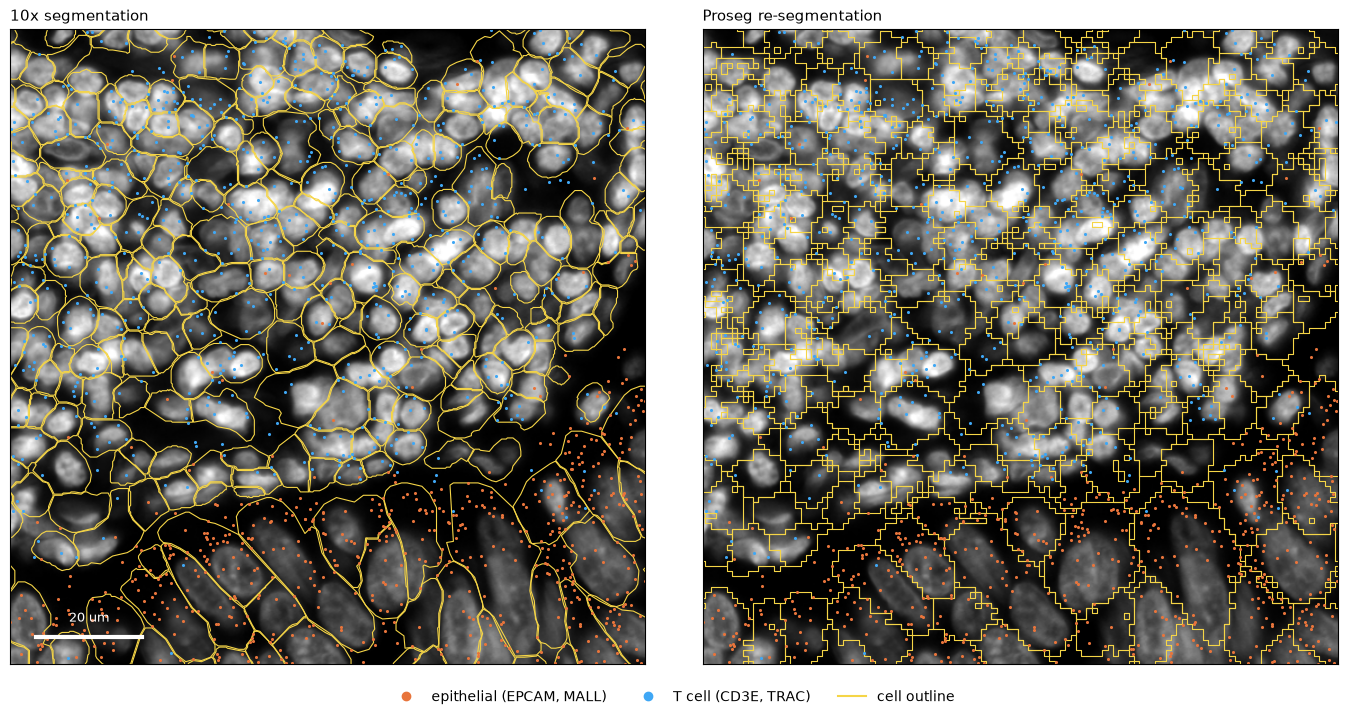

Same tissue, same transcripts. 10x outlines are fixed shapes grown from the stain images; Proseg outlines
follow where each cell's transcripts are, so a T cell's outline stops before the neighbouring tumour cell's
EPCAM / MALL transcripts. Proseg works on a 1 um voxel grid, hence its stepped edges.


In [6]:
import matplotlib.pyplot as plt
import tifffile
import zarr
from matplotlib.collections import PolyCollection

# ---- Look at it: outlines and transcripts on DAPI, before vs after ---------------------------
# Choose the window from the data: the 120 um tile where tumour and T cells meet most densely
# (highest min(epithelial transcripts, T-cell transcripts)), i.e. where spillover is most likely
W = 120
border = pd.read_parquet(xu.OUTS_DIR / "transcripts.parquet", columns=["feature_name", "x_location", "y_location", "qv"],
                         filters=[("feature_name", "in", ["EPCAM", "MALL", "CD3E", "TRAC"]), ("qv", ">=", 20)])
border["kind"] = np.where(border.feature_name.isin(["EPCAM", "MALL"]), "epi", "T")
border["tile"] = list(zip(border.x_location // W, border.y_location // W))
tile_counts = border.groupby(["tile", "kind"]).size().unstack(fill_value=0)
best = tile_counts.min(axis=1).idxmax()
X0, Y0 = best[0] * W, best[1] * W
print(f"Window: x {X0:.0f}-{X0 + W:.0f} um, y {Y0:.0f}-{Y0 + W:.0f} um "
      f"({tile_counts.loc[[best], 'epi'].iloc[0]} epithelial and {tile_counts.loc[[best], 'T'].iloc[0]} T-cell transcripts)")
win = lambda xy: (xy[:, 0] > X0) & (xy[:, 0] < X0 + W) & (xy[:, 1] > Y0) & (xy[:, 1] < Y0 + W)

px = xu.PIXEL_SIZE_UM
store = tifffile.imread(xu.OUTS_DIR / "morphology_focus" / "morphology_focus_0000.ome.tif", aszarr=True, level=0)
img = zarr.open(store, mode="r")          # reads only the tiles inside the window (JPEG 2000 via imagecodecs)
r0, c0, n = int(Y0 / px), int(X0 / px), int(W / px)
dapi = np.asarray(img[0, r0:r0 + n, c0:c0 + n] if img.ndim == 3 else img[r0:r0 + n, c0:c0 + n]).astype(float)
store.close()
lo, hi = np.percentile(dapi, [1, 99.7])

tx = pd.read_parquet(xu.OUTS_DIR / "transcripts.parquet", columns=["feature_name", "x_location", "y_location", "qv"],
                     filters=[("x_location", ">", X0), ("x_location", "<", X0 + W), ("y_location", ">", Y0), ("y_location", "<", Y0 + W)])
tx = tx[tx.qv >= 20]
SHOW = {"EPCAM": "#e8743b", "MALL": "#e8743b", "CD3E": "#3fa7f5", "TRAC": "#3fa7f5"}

b10 = pd.read_parquet(xu.OUTS_DIR / "cell_boundaries.parquet")
in_win_ids = b10.loc[win(b10[["vertex_x", "vertex_y"]].to_numpy()), "cell_id"].unique()
polys10 = [g[["vertex_x", "vertex_y"]].to_numpy() for _, g in b10[b10.cell_id.isin(in_win_ids)].groupby("cell_id", sort=False)]
gdf = pro_sd.shapes["cell_boundaries"]
cent = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])
polysP = [np.asarray(part.exterior.coords) for geom in gdf.geometry[win(cent)] for part in getattr(geom, "geoms", [geom])]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, polys, title in [(axes[0], polys10, "10x segmentation"), (axes[1], polysP, "Proseg re-segmentation")]:
    ax.imshow(np.clip((dapi - lo) / (hi - lo), 0, 1), cmap="gray", extent=[X0, X0 + W, Y0 + W, Y0])
    ax.add_collection(PolyCollection(polys, facecolors="none", edgecolors="#f5d547", linewidths=0.8))
    for gene, col in SHOW.items():
        t = tx[tx.feature_name == gene]
        ax.scatter(t.x_location, t.y_location, s=5, c=col, linewidths=0)
    ax.set_xlim(X0, X0 + W); ax.set_ylim(Y0 + W, Y0); ax.set_title(title, loc="left", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
axes[0].plot([X0 + 5, X0 + 25], [Y0 + W - 5] * 2, color="white", lw=3)
axes[0].text(X0 + 15, Y0 + W - 8, "20 um", color="white", ha="center", fontsize=9)
fig.legend(handles=[plt.Line2D([], [], marker="o", ls="", color="#e8743b", label="epithelial (EPCAM, MALL)"),
                    plt.Line2D([], [], marker="o", ls="", color="#3fa7f5", label="T cell (CD3E, TRAC)"),
                    plt.Line2D([], [], color="#f5d547", label="cell outline")], loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()
print("Same tissue, same transcripts. 10x outlines are fixed shapes grown from the stain images; Proseg outlines\n"
      "follow where each cell's transcripts are, so a T cell's outline stops before the neighbouring tumour cell's\n"
      "EPCAM / MALL transcripts. Proseg works on a 1 um voxel grid, hence its stepped edges.")

## D. Export for the core workflow

The Proseg counts are saved as an AnnData file in the same layout the core workflow expects: raw counts, cell area, centroids in µm, indexed by the original 10x cell ids.

**Privacy note:** Proseg stores its full command line, including local file paths, inside its output (`uns['proseg_run']`). Only the version and method are carried into the exported file.

Part E uses this file to test whether the biological conclusions of the core workflow survive re-segmentation.

In [7]:
# ---- Export: Proseg counts as an AnnData the core workflow can read ------------------------
# indexed by the 10x cell ids; Proseg's own uns['proseg_run'] stores its command line with local paths and is not copied
out = proseg.export_counts(pro, pro_area)
EXPORT = OUT_DIR / f"{xu.SAMPLE}_proseg_counts.h5ad"
out.write_h5ad(EXPORT, compression="gzip")
print(f"Saved {out.n_obs:,} cells x {out.n_vars} genes to {xu.display_path(EXPORT)}")
print("Next: a SEGMENTATION = 'proseg' switch in the core workflow reads this file instead of the 10x matrix\n"
      "and re-runs Steps 4-10 with identical code, so the comparison isolates the effect of segmentation.")

Saved 155,468 cells x 377 genes to ~/data/xenium_lung/processed/resegmentation/Xenium_V1_humanLung_Cancer_FFPE_proseg_counts.h5ad
Next: a SEGMENTATION = 'proseg' switch in the core workflow reads this file instead of the 10x matrix
and re-runs Steps 4-10 with identical code, so the comparison isolates the effect of segmentation.


## E. Does re-segmentation change the biology?

Parts A-D showed the Proseg cells are cleaner. Part E asks the question that matters for the conclusions: **which findings of the core workflow hold on cleaner cells, which were segmentation artefacts, and what becomes newly visible?**

| Part | Approach |
|---|---|
| E1 | Re-discover cell types on Proseg cells with the core recipe (QC, normalise, PCA, Leiden); then the key test: re-cluster the T/NK cells and look for clean CD4 T and Treg groups |
| E2 | Same cells, same Step 6 labels, Proseg vs 10x counts: re-measure the Step 9 CD8 T-cell gradient and checkpoint expression |
| E3 | Re-test CD8 T exclusion and the TLS aggregates on Proseg cell positions |
| E4 | One table: holds / changes / removed / newly visible |

Runtime ~1 min (UMAP is skipped: it is for viewing only and adds ~3 min).

### E1. Cell types on Proseg cells

**Finding:** 143,975 cells pass the same QC; Leiden finds 14 clusters (as with 10x) that map onto the same cell types (agreement with the 10x-based clusters, ARI 0.52).

In [8]:
# ---- E1. Re-discover cell types on the Proseg cells (same recipe as core Steps 4-5) ----------
from sklearn.metrics import adjusted_rand_score

warnings.filterwarnings("ignore", message="zero-centering")   # scanpy notice when scaling sparse data

pc, (area_lo, area_hi) = proseg.qc_proseg(sc.read_h5ad(EXPORT))   # core QC rules (counts, genes, 3-MAD area)
print(f"QC (counts >= 10, genes >= 5, area {area_lo:.0f}-{area_hi:.0f} um^2): {pc.n_obs:,} Proseg cells kept "
      f"(10x: 154,394). Proseg output has no control probes, so the control-fraction rule does not apply.")

cluster.normalise_and_pca(pc)                                       # same recipe as core Step 5
cluster.cluster(pc, n_pcs=30, n_neighbors=15, resolutions=[0.5], seed=0, umap=False)
pc.obs["leiden"] = pc.obs["leiden_0.5"]
print(f"Leiden (resolution 0.5): {pc.obs['leiden'].nunique()} clusters (10x-based: 14). UMAP skipped: it is for viewing only.\n")

# Labels from the core workflow, carried across by cell id
step6 = labels.reindex(pc.obs_names)
tenx_clusters = xu.load_step("clustered", backed="r").obs["leiden_0.5"]
shared = pc.obs_names.intersection(tenx_clusters.index)
print(f"Cluster agreement with the 10x-based clustering (ARI, {len(shared):,} shared cells): "
      f"{adjusted_rand_score(tenx_clusters[shared], pc.obs.loc[shared, 'leiden']):.2f}\n")

sc.tl.rank_genes_groups(pc, "leiden", method="wilcoxon", layer="lognorm", key_added="markers")
top = sc.get.rank_genes_groups_df(pc, group=None, key="markers").query("pvals_adj < 0.01 and logfoldchanges > 1")
top6 = top.groupby("group", observed=True).head(6).groupby("group", observed=True)["names"].apply(", ".join)
purity = (pd.crosstab(pc.obs["leiden"], step6["cell_type"], normalize="index") * 100)
summary = pd.DataFrame({
    "cells": pc.obs["leiden"].value_counts().reindex(top6.index),
    "top markers": top6,
    "main Step 6 label": purity.idxmax(axis=1).reindex(top6.index),
    "% of cluster": purity.max(axis=1).reindex(top6.index).round(0),
})
display(summary)

QC (counts >= 10, genes >= 5, area 12-399 um^2): 143,975 Proseg cells kept (10x: 154,394). Proseg output has no control probes, so the control-fraction rule does not apply.
Leiden (resolution 0.5): 14 clusters (10x-based: 14). UMAP skipped: it is for viewing only.

Cluster agreement with the 10x-based clustering (ARI, 141,396 shared cells): 0.52



,cells,top markers,main Step 6 label,% of cluster
group,,,,
0,19208,"MALL, EPCAM, SFTA2, TCIM, PCSK2, CFB",Tumour epithelial (MALL/TCIM),72.0
1,24336,"CYP2B6, TCIM, TFPI, MALL, CAPN8, CFTR",Tumour epithelial (CYP2B6/CFTR),84.0
2,12181,"CYP4B1, CAPN8, MYC, MLPH, EHF, CYP2B6",Tumour epithelial (MYC/CAPN8),79.0
3,1324,"FCGR3A, MCEMP1, AIF1, MRC1, CD68, C1orf162",Myeloid / epithelial mixed,63.0
4,12968,"MS4A6A, AIF1, MRC1, CD163, MS4A4A, C1orf162",cDC2,17.0
5,22491,"KRT7, EPCAM, GPRC5A, MYC, STEAP4, MET",Tumour epithelial (MYC/CAPN8),59.0
6,16506,"LTBP2, MYLK, FBN1, PDGFRA, PDGFRB, COL5A2",Fibroblast,78.0
7,17937,"TRAC, CXCR4, IL7R, PTPRC, CD3E, CD2",CD8 T (GZMK+),19.0
8,7808,"PECAM1, VWF, CAVIN1, CD93, CLEC14A, CD34",Endothelial,92.0


### E1b. The key test: CD4 T cells and Tregs

A subcluster counts as **clean** only if it passes explicit thresholds, and every foreign lineage (epithelial, macrophage, endothelial, fibroblast, mregDC) is below 25%.

**Finding, reported honestly:**
- A **clean Treg population emerges** (FOXP3 ~53%, CTLA4, IL2RA; no foreign lineage above ~10%). The 10x-based R workflow had merged Tregs with CD4 T cells.
- **No clean conventional CD4 T population**, even after re-segmentation. The CD4-leaning candidates still carry mregDC (CCR7/LAMP3 group, ~26%) or fibroblast transcripts (35-56%). Proseg removes tumour-to-immune spillover but not immune-stromal and immune-DC overlaps in the dense TLS and stroma, where cells sit tightly packed in a 5 µm 2D section. CD4 is also weakly detected on this panel (~30% of cells even in CD4-leaning groups).
- An earlier version of this test reported four 'clean CD4 T' subclusters. It had no fibroblast probe and did not exclude Tregs; adding both removed every false positive. Validation rules need the same scrutiny as the data.

In [9]:
# ---- The key test: do CD4 T cells form a clean group on Proseg cells? ------------------------
lineage_of_cluster = pd.crosstab(pc.obs["leiden"], step6["lineage"]).idxmax(axis=1)
tnk_clusters = lineage_of_cluster.index[lineage_of_cluster == "T / NK"]
tnk = annotate.subcluster(pc, "leiden", list(tnk_clusters), resolution=0.6)   # same recipe as core Step 6c

PROBES, FOREIGN = proseg.TNK_PROBES, proseg.FOREIGN
rates = proseg.tnk_probe_rates(tnk)   # % of cells per subcluster with each lineage's transcripts
sub_top = sc.get.rank_genes_groups_df(tnk, group=None, key="sub_markers").groupby("group", observed=True).head(6) \
    .groupby("group", observed=True)["names"].apply(", ".join)
sub_table = rates.join(sub_top.rename("top markers")).join(tnk.obs["sub"].value_counts().rename("cells"))
display(sub_table)

# Conventional CD4 T: CD4-leaning, T-cell positive, not Treg, and no other lineage's markers at high rates
# CD4 >= 30%, T >= 60%, CD8A < 20%, every foreign lineage < 25%; Treg = FOXP3 >= 25%
clean_cd4, clean_treg = proseg.clean_cd4_treg(sub_table)
print(f"T/NK cells re-clustered: {tnk.n_obs:,} in {tnk.obs['sub'].nunique()} subclusters.")
print("Clean conventional CD4 T (CD4 >= 30%, T >= 60%, CD8A < 20%, FOXP3 < 25%, every foreign lineage < 25%): "
      + (", ".join(f"{i} ({int(r.cells):,} cells)" for i, r in clean_cd4.iterrows()) if len(clean_cd4) else "none"))
print("Clean Treg (same, FOXP3 >= 25%): "
      + (", ".join(f"{i} ({int(r.cells):,} cells)" for i, r in clean_treg.iterrows()) if len(clean_treg) else "none"))

,CD4,CD8A,FOXP3,T (CD3E/TRAC),epithelial,macrophage,endothelial,fibroblast,mregDC,top markers,cells
0,21.0,34.0,4.0,91.0,0.0,4.0,10.0,6.0,3.0,"CCL5, GZMA, GZMK, CD3E, CXCR4, CD8A",4065
1,30.0,13.0,10.0,85.0,0.0,6.0,7.0,11.0,26.0,"CCL19, CCR7, CXCL9, LAMP3, IL7R, BASP1",2216
10,28.0,15.0,13.0,83.0,7.0,5.0,14.0,10.0,5.0,"STEAP4, TCIM, GPRC5A, CAPN8, CD2, MEF2C",146
2,34.0,19.0,14.0,89.0,1.0,11.0,19.0,56.0,2.0,"SFRP4, COL5A2, VCAN, FBN1, ACTA2, ASPN",1408
3,31.0,16.0,6.0,91.0,1.0,11.0,37.0,21.0,8.0,"MMRN1, ECSCR, CD34, ADGRL4, TFPI, CLEC14A",563
4,13.0,33.0,4.0,73.0,2.0,8.0,18.0,8.0,3.0,"KLRD1, GNLY, PRF1, KLRC1, CCL5, NKG7",554
5,34.0,17.0,7.0,84.0,0.0,10.0,19.0,35.0,3.0,"PTGDS, FBLN1, INMT, MYLK, C7, PMP22",3535
6,42.0,17.0,8.0,88.0,0.0,52.0,13.0,14.0,2.0,"AIF1, MRC1, MS4A4A, CD14, IGSF6, CD163",3203
7,40.0,7.0,53.0,95.0,0.0,7.0,8.0,10.0,3.0,"CTLA4, FOXP3, TRAC, CD28, IL2RA, PTPRC",940
8,32.0,22.0,12.0,92.0,1.0,11.0,10.0,11.0,3.0,"PCNA, MKI67, TRAC, TOP2A, CDK1, CD3D",747


T/NK cells re-clustered: 17,937 in 11 subclusters.
Clean conventional CD4 T (CD4 >= 30%, T >= 60%, CD8A < 20%, FOXP3 < 25%, every foreign lineage < 25%): none
Clean Treg (same, FOXP3 >= 25%): 7 (940 cells)


### E2. Same cells, same labels: per-cell findings with 10x vs Proseg counts

**The critical test of Step 9b.** With 10x counts, CD8 T cells lost CCR7 toward the tumour, but epithelial spillover (EPCAM, MALL) rose in the same direction, so the two could not be separated. On Proseg cells:
- the **spillover control flattens to ~0%** (EPCAM 8% -> 0.7%, MALL 14% -> 0% at tumour contact), while
- the **CCR7 gradient persists** (25% -> 9%), GZMA still rises (30% -> 48%) and CTLA4 still falls.

**The effector-like shift of CD8 T cells at the tumour border is real biology, not spillover.** Checkpoint expression (Step 9a) is unchanged: PD-L1 stays on CXCL9+ macrophages and mregDCs (~10%), at the noise floor on tumour (0.6%).

In [10]:
# ---- E2. Same cells, same labels, different segmentation: re-measure per-cell findings --------
# Labels and locations (TLS / stroma / border / tumour contact) come from the core workflow by cell id;
# only the expression changes (10x counts vs Proseg counts).
time_obs = xu.load_step("time", backed="r").obs[["cell_type", "cd8_compartment"]]
COMPARTMENTS = list(time_obs["cd8_compartment"].cat.categories)
GENES = ["CCR7", "IL7R", "GZMA", "CTLA4", "HAVCR2", "EPCAM", "MALL"]
e2, n_cd8 = proseg.cd8_by_segmentation(tenx, pro, time_obs, GENES)
display(e2.loc[GENES])
print(f"{n_cd8:,} CD8 T cells (Step 6 label), % positive by location. EPCAM / MALL are the spillover control:\n"
      "if they flatten on Proseg cells while CCR7 / GZMA keep their gradient, the gradient is real biology.")

# Checkpoint expression (Step 9a): % positive within cell type, 10x vs Proseg
types = ["CXCL9+ macrophage", "mregDC (LAMP3+)", "CD163+ macrophage", "CD8 T (GZMK+)", "Treg"]
ann_types = labels["cell_type"]
tumour = ann_types.index[ann_types.isin(xu.TUMOUR_TYPES)].intersection(pro.obs_names)
chk = []
for gene in ["CD274", "PDCD1", "CTLA4", "HAVCR2"]:
    for seg, adata in [("10x", tenx), ("Proseg", pro)]:
        row = {"gene": gene, "segmentation": seg,
               "Tumour (noise floor)": 100 * (sp.csr_matrix(adata[tumour, [gene]].X) > 0).mean()}
        for t in types:
            cells = ann_types.index[ann_types == t].intersection(pro.obs_names)
            row[t] = 100 * (sp.csr_matrix(adata[cells, [gene]].X) > 0).mean()
        chk.append(row)
display(pd.DataFrame(chk).set_index(["gene", "segmentation"]).round(1))

TLS  Stroma (> 50 um)  Border (15-50 um)  \
gene   segmentation                                              
CCR7   10x           35.9              29.5               22.0   
       Proseg        24.8              19.6               17.0   
IL7R   10x           73.6              69.4               67.5   
       Proseg        69.6              65.9               64.4   
GZMA   10x           29.9              40.3               38.1   
       Proseg        29.8              40.1               37.7   
CTLA4  10x           36.7              28.3               25.0   
       Proseg        33.4              27.0               25.1   
HAVCR2 10x            3.8               5.2                5.0   
       Proseg         3.7               6.9                5.0   
EPCAM  10x            1.4               1.7                4.2   
       Proseg         0.3               0.0                0.4   
MALL   10x            3.2               3.0                7.1   
       Proseg         0.0               0.2                0.1   

                     Tumour contact (<= 15 um)  
gene   segmentation                             
CCR7   10x                                11.0  
       Proseg                              9.4  
IL7R   10x                                52.9  
       Proseg                             56.3  
GZMA   10x                                44.8  
       Proseg                             48.4  
CTLA4  10x                                19.5  
       Proseg                             20.9  
HAVCR2 10x                                 7.6  
       Proseg                              7.4  
EPCAM  10x                                 8.1  
       Proseg                              0.7  
MALL   10x                                13.9  
       Proseg                              0.0

3,781 CD8 T cells (Step 6 label), % positive by location. EPCAM / MALL are the spillover control:
if they flatten on Proseg cells while CCR7 / GZMA keep their gradient, the gradient is real biology.


Tumour (noise floor)  CXCL9+ macrophage  mregDC (LAMP3+)  \
gene   segmentation                                                             
CD274  10x                            0.9               12.0             13.4   
       Proseg                         0.6                9.6             10.6   
PDCD1  10x                            0.1                0.4              0.6   
       Proseg                         0.1                0.4              0.4   
CTLA4  10x                            2.7                5.6             18.8   
       Proseg                         2.0                6.0             17.7   
HAVCR2 10x                            2.8               32.3              8.0   
       Proseg                         1.0               32.7              7.1   

                     CD163+ macrophage  CD8 T (GZMK+)  Treg  
gene   segmentation                                          
CD274  10x                         1.3            2.0   1.6  
       Proseg                      1.4            2.0   1.6  
PDCD1  10x                         0.2            0.9   0.4  
       Proseg                      0.1            1.0   0.6  
CTLA4  10x                         5.7           27.3  69.5  
       Proseg                      5.2           26.6  65.5  
HAVCR2 10x                        24.9            5.2   8.2  
       Proseg                     30.0            5.6   7.8

### E3. Spatial findings on Proseg cell positions

**Finding:** CD8 T exclusion holds (12% within 15 µm of tumour vs. a 34% baseline), the myeloid / stromal tumour border holds, and **all six TLS-like aggregates are found again within 3-9 µm of their 10x positions**.

In [11]:
# ---- E3. Spatial findings with Proseg cell positions ------------------------------------------
from scipy.spatial import cKDTree

xy, types_hc = proseg.positions_high_confidence(out, labels)   # Proseg centroids of high-confidence cells
excl, base = proseg.exclusion_on_positions(xy, types_hc, xu.TUMOUR_TYPES,
                                           ["CD8 T (GZMK+)", "B cell", "Alveolar macrophage", "cDC2", "Fibroblast"])
print(f"Proseg positions: baseline (all non-tumour cells) {100 * base:.0f}% within 15 um of a tumour cell")
display(excl.round(1))

centres = proseg.aggregates_on_positions(xy, types_hc)   # DBSCAN eps 25 um, min 20 B cells
py_tls = xu.load_step("spatial", backed="r")
py_obs = py_tls.obs[["tls_id"]].assign(x=py_tls.obsm["spatial"][:, 0], y=py_tls.obsm["spatial"][:, 1])
py_centres = py_obs[py_obs.tls_id != "none"].groupby("tls_id", observed=True)[["x", "y"]].mean()
dist_to_py = cKDTree(py_centres.to_numpy()).query(centres, k=1)
tls_match = pd.DataFrame({"Proseg aggregate": [f"A{i + 1}" for i in range(len(centres))],
                          "nearest 10x TLS": py_centres.index[dist_to_py[1]], "distance (um)": dist_to_py[0].round(0)})
print(f"\nB-cell aggregates on Proseg positions (DBSCAN eps 25 um, min 20): {len(centres)}; "
      f"{(dist_to_py[0] <= 100).sum()} lie within 100 um of a 10x-based TLS")
display(tls_match)

Proseg positions: baseline (all non-tumour cells) 34% within 15 um of a tumour cell


,median distance (um),% within 15 um
cell type,,
CD8 T (GZMK+),37.1,12.2
B cell,45.0,7.4
Alveolar macrophage,12.2,68.0
cDC2,14.1,54.1
Fibroblast,15.2,49.0



B-cell aggregates on Proseg positions (DBSCAN eps 25 um, min 20): 6; 6 lie within 100 um of a 10x-based TLS


,Proseg aggregate,nearest 10x TLS,distance (um)
0,A1,TLS1,3.0
1,A2,TLS2,3.0
2,A3,TLS3,9.0
3,A4,TLS4,7.0
4,A5,TLS5,5.0
5,A6,TLS6,7.0


### E4. Which conclusions survive re-segmentation?

**Bottom line:** every headline finding of the core workflow is robust to segmentation (CD8 T exclusion, TLS, the CD8 T-cell gradient, checkpoint expression). What re-segmentation changes is *noise*: tumour-to-immune spillover is removed, which turns the Step 9b gradient from 'possibly an artefact' into a confirmed result and resolves a clean Treg population. Conventional CD4 T cells remain unresolved, a limitation of 2D segmentation in dense immune-stromal zones and of CD4 detection on this panel.

In [12]:
# ---- E4. Which conclusions survive re-segmentation? -------------------------------------------
cd8_contact = excl.loc["CD8 T (GZMK+)", "% within 15 um"]
ccr7 = e2.loc[("CCR7", "Proseg")]; epcam10, epcamP = e2.loc[("EPCAM", "10x")], e2.loc[("EPCAM", "Proseg")]
verdict = pd.DataFrame([
    ["Tumour-to-immune transcript spillover", "T/NK cells with epithelial transcripts 18.8%",
     f"{spill.iloc[0]['Proseg: % positive']:.1f}%", "reduced 10x+ (segmentation artefact)"],
    ["CD8 T cells excluded from tumour", "12-16% within 15 um vs 35% baseline",
     f"{cd8_contact:.0f}% vs {100 * base:.0f}% baseline", "holds" if cd8_contact < 0.8 * 100 * base else "changes"],
    ["TLS-like B-cell aggregates", "6 aggregates", f"{len(centres)} aggregates, {(dist_to_py[0] <= 100).sum()} at 10x TLS positions",
     "holds" if (dist_to_py[0] <= 100).sum() >= 5 else "changes"],
    ["CD8 T cells lose CCR7 toward tumour", "36% (TLS) -> 11% (contact)",
     f"{ccr7['TLS']:.0f}% -> {ccr7['Tumour contact (<= 15 um)']:.0f}%",
     "holds" if ccr7["TLS"] > 2 * ccr7["Tumour contact (<= 15 um)"] else "weakens"],
    ["Epithelial spillover in tumour-contact CD8 T cells", f"EPCAM {epcam10['Tumour contact (<= 15 um)']:.0f}% at contact",
     f"EPCAM {epcamP['Tumour contact (<= 15 um)']:.0f}% at contact", "removed by re-segmentation"],
    ["Clean conventional CD4 T population", "none (always 'mixed')",
     f"{len(clean_cd4)} clean subcluster(s)", "newly visible" if len(clean_cd4) else "still not resolved"],
    ["Clean Treg population", "Treg subcluster (Python) / merged with CD4 T (R)",
     f"{len(clean_treg)} clean subcluster(s)", "resolved" if len(clean_treg) else "not resolved"],
], columns=["finding", "10x segmentation", "Proseg", "verdict"]).set_index("finding")
display(verdict)

,10x segmentation,Proseg,verdict
finding,,,
Tumour-to-immune transcript spillover,T/NK cells with epithelial transcripts 18.8%,1.5%,reduced 10x+ (segmentation artefact)
CD8 T cells excluded from tumour,12-16% within 15 um vs 35% baseline,12% vs 34% baseline,holds
TLS-like B-cell aggregates,6 aggregates,"6 aggregates, 6 at 10x TLS positions",holds
CD8 T cells lose CCR7 toward tumour,36% (TLS) -> 11% (contact),25% -> 9%,holds
Epithelial spillover in tumour-contact CD8 T cells,EPCAM 8% at contact,EPCAM 1% at contact,removed by re-segmentation
Clean conventional CD4 T population,none (always 'mixed'),0 clean subcluster(s),still not resolved
Clean Treg population,Treg subcluster (Python) / merged with CD4 T (R),1 clean subcluster(s),resolved
